## Module 3: Vibe Mapping & Playlist Recommendation

**Objective:** Wire in the CLIP image encoder to build the full end-to-end pipeline:
image → vibe detection → cosine similarity → diverse playlist → evaluation.

**Key Operations:**
* **Vibe Taxonomy:** 12 scene categories, each defined by a natural-language probe text and a label.
* **Vibe Detection:** Encode the uploaded image and compare it against all vibe probes to identify the dominant scene type.
* **Song Representation:** Each song is represented as a natural-language sentence (see `01_data_cleaning.ipynb`), not raw audio features. This is what enables meaningful cosine similarity with image embeddings in CLIP's shared space.
* **Genre Filtering:** Children's genres (`children`, `kids`, `disney`) are permanently excluded from the song pool.
* **Recommendation:** Rank the filtered song pool by cosine similarity to the image embedding and return a diverse top-K playlist.
* **Baselines:** Popularity-based and random baselines are included for comparison against the CLIP pipeline.
* **Evaluation:** A labeled test set builder and user study protocol are included for demo-day assessment.


---
Requires outputs from `02_clip_setup.ipynb`:
- `data/song_embeddings.npy` — precomputed song text embeddings `[61670, 512]`
- `data/song_index.csv` — row-aligned song metadata

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pillow-heif', '--quiet'], check=True)

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import clip
from PIL import Image
import pillow_heif
pillow_heif.register_heif_opener()   # adds HEIC/HEIF support to PIL

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

song_embeddings_all = np.load("../data/song_embeddings.npy")
index_df_all        = pd.read_csv("../data/song_index.csv")

assert len(song_embeddings_all) == len(index_df_all), "Embedding matrix and index are misaligned."

# Permanently remove children's genres from the song pool
KIDS_GENRES = "children|kids|disney"
keep_mask       = ~index_df_all["merged_genres"].str.contains(KIDS_GENRES, case=False, na=False)
song_embeddings = song_embeddings_all[keep_mask.values]
index_df        = index_df_all[keep_mask.values].reset_index(drop=True)

print(f"Device              : {device}")
print(f"Total songs loaded  : {len(index_df_all):,}")
print(f"After kids filter   : {len(index_df):,} ({len(index_df_all)-len(index_df):,} removed)")
print(f"Song embeddings     : {song_embeddings.shape}")

Device              : cpu
Total songs loaded  : 61,670
After kids filter   : 60,082 (1,588 removed)
Song embeddings     : (60082, 512)


---
### 1. Vibe taxonomy

Each vibe is defined by:
- A **label**: short human-readable name shown to the user
- A **probe**: natural-language description that CLIP encodes into a 512-d vector

Vibe detection works by comparing the image embedding to all probe embeddings and picking the closest match.

In [2]:
VIBE_TAXONOMY = {
    "cozy_cafe": {
        "label": "Cozy Cafe",
        "probe": "a cozy coffee shop with warm lighting and soft background music",
    },
    "winter_snow": {
        "label": "Winter / Snow",
        "probe": "a quiet snowy street on a cold winter evening",
    },
    "beach_summer": {
        "label": "Beach / Summer",
        "probe": "a bright sunny beach in summer with people relaxing",
    },
    "rainy_melancholic": {
        "label": "Rainy / Melancholic",
        "probe": "a rainy night alone in the city feeling nostalgic and sad",
    },
    "party_energetic": {
        "label": "Party / Energetic",
        "probe": "a high-energy dance party with flashing lights and a dancing crowd",
    },
    "romantic_evening": {
        "label": "Romantic Evening",
        "probe": "a candlelit romantic dinner setting at night",
    },
    "nature_peaceful": {
        "label": "Nature / Peaceful",
        "probe": "a peaceful walk through green forests and nature trails",
    },
    "urban_hustle": {
        "label": "Urban / Hustle",
        "probe": "a busy city street at midday with crowds and tall buildings",
    },
    "late_night_drive": {
        "label": "Late Night Drive",
        "probe": "driving alone on a dark highway at night with city lights in the distance",
    },
    "morning_calm": {
        "label": "Morning / Calm",
        "probe": "a calm peaceful morning at home with soft sunlight coming through the window",
    },
    "dark_moody": {
        "label": "Dark / Moody",
        "probe": "a dark moody aesthetic with deep shadows and muted tones",
    },
    "festival_concert": {
        "label": "Festival / Concert",
        "probe": "an outdoor music festival with a large crowd and a stage",
    },
}

vibe_keys   = list(VIBE_TAXONOMY.keys())
vibe_labels = [VIBE_TAXONOMY[k]["label"] for k in vibe_keys]
vibe_probes = [VIBE_TAXONOMY[k]["probe"] for k in vibe_keys]

print(f"{len(VIBE_TAXONOMY)} vibes defined:")
for key, label in zip(vibe_keys, vibe_labels):
    print(f"  {key:22s} → {label}")

12 vibes defined:
  cozy_cafe              → Cozy Cafe
  winter_snow            → Winter / Snow
  beach_summer           → Beach / Summer
  rainy_melancholic      → Rainy / Melancholic
  party_energetic        → Party / Energetic
  romantic_evening       → Romantic Evening
  nature_peaceful        → Nature / Peaceful
  urban_hustle           → Urban / Hustle
  late_night_drive       → Late Night Drive
  morning_calm           → Morning / Calm
  dark_moody             → Dark / Moody
  festival_concert       → Festival / Concert


In [3]:
# Precompute vibe probe embeddings — shape: [12, 512]
with torch.no_grad():
    tokens = clip.tokenize(vibe_probes, truncate=True).to(device)
    vibe_embeddings = model.encode_text(tokens)
    vibe_embeddings = F.normalize(vibe_embeddings, dim=-1).cpu().numpy()

print(f"Vibe probe embedding matrix: {vibe_embeddings.shape}")

Vibe probe embedding matrix: (12, 512)


---
### 2. Spotify API Integration

The cells below authenticate with the Spotify Web API and add three capabilities:

| Capability | Function | Auth required |
|---|---|---|
| Track lookup (ID, URL, preview) | `spotify_search_track()` | Client credentials |
| Enrich playlist DataFrame | `enrich_playlist_with_spotify()` | Client credentials |
| Push playlist to a user account | `create_spotify_playlist()` | OAuth (user login) |

**Setup:** Create an app at [developer.spotify.com](https://developer.spotify.com/dashboard), set the redirect URI to `http://localhost:8888/callback`, then set credentials as environment variables — never commit them to git:
```
export SPOTIPY_CLIENT_ID='your_client_id'
export SPOTIPY_CLIENT_SECRET='your_client_secret'
export SPOTIPY_REDIRECT_URI='http://localhost:8888/callback'
```


In [4]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'spotipy', '--quiet'], check=True)

import spotipy, os
from spotipy.oauth2 import SpotifyOAuth, SpotifyClientCredentials

SPOTIPY_CLIENT_ID     = os.getenv('SPOTIPY_CLIENT_ID',     'YOUR_CLIENT_ID')
SPOTIPY_CLIENT_SECRET = os.getenv('SPOTIPY_CLIENT_SECRET', 'YOUR_CLIENT_SECRET')
SPOTIPY_REDIRECT_URI  = os.getenv('SPOTIPY_REDIRECT_URI',  'YOUR_REDIRECT_URI')

# Client-credentials: read-only search/metadata (no user login needed)
sp_cc = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=SPOTIPY_CLIENT_ID,
    client_secret=SPOTIPY_CLIENT_SECRET,
))

# OAuth: required for playlist creation on a user account
PLAYLIST_SCOPE = 'playlist-modify-public playlist-modify-private'
sp_oauth = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=SPOTIPY_CLIENT_ID,
    client_secret=SPOTIPY_CLIENT_SECRET,
    redirect_uri=SPOTIPY_REDIRECT_URI,
    scope=PLAYLIST_SCOPE,
))

print('Spotify clients initialised.')
print('  sp_cc    — client-credentials (search / metadata)')
print('  sp_oauth — OAuth (playlist creation)')


Spotify clients initialised.
  sp_cc    — client-credentials (search / metadata)
  sp_oauth — OAuth (playlist creation)


In [5]:
import time

_spotify_cache: dict = {}   # (track_name, artist) -> hit dict | None

def spotify_search_track(track_name: str, artist: str, retries: int = 2) -> dict | None:
    """
    Search Spotify for a track. Returns a dict with keys:
        id, name, artists, album, uri, external_url, preview_url
    Returns None if not found. Results are cached within the session.
    """
    key = (track_name.lower().strip(), artist.lower().strip())
    if key in _spotify_cache:
        return _spotify_cache[key]

    clean_name     = track_name.split('(feat')[0].split('(with')[0].strip()
    primary_artist = artist.split(',')[0].split(';')[0].strip()

    query = f'track:"{clean_name}" artist:"{primary_artist}"'
    for attempt in range(retries + 1):
        try:
            results = sp_cc.search(q=query, type='track', limit=1)
            items   = results.get('tracks', {}).get('items', [])
            if items:
                t   = items[0]
                hit = {
                    'id'          : t['id'],
                    'name'        : t['name'],
                    'artists'     : ', '.join(a['name'] for a in t['artists']),
                    'album'       : t['album']['name'],
                    'uri'         : t['uri'],
                    'external_url': t['external_urls'].get('spotify', ''),
                    'preview_url' : t.get('preview_url'),
                }
                _spotify_cache[key] = hit
                return hit
        except spotipy.exceptions.SpotifyException as e:
            if e.http_status == 429:
                time.sleep(int(e.headers.get('Retry-After', 2)) + 1)
            else:
                break
    _spotify_cache[key] = None
    return None


def enrich_playlist_with_spotify(playlist_df: 'pd.DataFrame') -> 'pd.DataFrame':
    """
    Add spotify_id, spotify_url, spotify_uri, preview_url columns to the playlist DataFrame.
    Tracks not found on Spotify receive None in those columns.
    Playlist is capped at 10 songs to stay within free API usage.
    """
    df = playlist_df.head(10).copy()
    ids, urls, uris, previews = [], [], [], []
    for _, row in df.iterrows():
        hit = spotify_search_track(row['track_name'], row['artists'])
        ids.append(hit['id']           if hit else None)
        urls.append(hit['external_url'] if hit else None)
        uris.append(hit['uri']          if hit else None)
        previews.append(hit['preview_url'] if hit else None)
    df['spotify_id']  = ids
    df['spotify_url'] = urls
    df['spotify_uri'] = uris
    df['preview_url'] = previews
    return df


def create_spotify_playlist(
    playlist_df: 'pd.DataFrame',
    playlist_name: str,
    description: str = '',
    public: bool = False,
) -> str:
    """
    Create a Spotify playlist from a DataFrame with a 'spotify_uri' column.
    Requires sp_oauth (OAuth flow). Capped at 10 tracks. Returns the playlist URL.
    """
    user_id  = sp_oauth.me()['id']
    playlist = sp_oauth.user_playlist_create(
        user_id, playlist_name, public=public, description=description
    )
    uris = playlist_df['spotify_uri'].dropna().tolist()[:10]  # cap at 10
    if uris:
        sp_oauth.playlist_add_items(playlist['id'], uris)
    url = playlist['external_urls']['spotify']
    print(f'Playlist created ({len(uris)} tracks): {url}')
    return url


print('Spotify helpers defined:')
print('  spotify_search_track()         — look up a single track')
print('  enrich_playlist_with_spotify() — add Spotify links to playlist DataFrame (capped at 10)')
print('  create_spotify_playlist()      — push playlist to Spotify account (capped at 10)')


Spotify helpers defined:
  spotify_search_track()         — look up a single track
  enrich_playlist_with_spotify() — add Spotify links to playlist DataFrame (capped at 10)
  create_spotify_playlist()      — push playlist to Spotify account (capped at 10)


In [6]:
# Quick connectivity test — verify credentials before running the full pipeline
hit = spotify_search_track('Blinding Lights', 'The Weeknd')
if hit:
    print(f"Found : {hit['name']} by {hit['artists']}")
    print(f"  URL : {hit['external_url']}")
    print(f"  URI : {hit['uri']}")
    print(f"  Preview : {hit['preview_url']}")
else:
    print('Track not found — check your API credentials.')


Found : Blinding Lights by The Weeknd
  URL : https://open.spotify.com/track/0VjIjW4GlUZAMYd2vXMi3b
  URI : spotify:track:0VjIjW4GlUZAMYd2vXMi3b
  Preview : None


---
### 3. Image-to-Playlist Pipeline

The full pipeline in five steps:

```
1. Image  ──► CLIP image encoder  ──► 512-d image embedding
                                              │
2.                                  cosine sim vs 12 vibe probes  ──► top vibe label
                                              │
3.                              cosine sim vs ~61K song embeddings
                                              │
4.                  diverse_top_k(): artist cap + genre spread filter
                                              │
5.                       Spotify lookup ──► URLs / URIs / optional playlist push
```

**Diversity parameters** (tunable per call):

| Parameter | Default | Effect |
|---|---|---|
| `max_per_artist` | `2` | No artist appears more than N times |
| `min_genre_spread` | `3` | Extends selection until ≥ N distinct genre tokens are covered |


In [7]:
def diverse_top_k(
    sims: 'np.ndarray',
    index_df: 'pd.DataFrame',
    top_k: int = 10,
    max_per_artist: int = 2,
    min_genre_spread: int = 3,
) -> list:
    """
    Return up to top_k song indices satisfying diversity constraints:
      - max_per_artist  : no primary artist contributes more than this many tracks
      - min_genre_spread: extend past top_k until this many distinct genre tokens
                          are covered (soft; capped at 1.5 * top_k)
    """
    ranked         = np.argsort(sims)[::-1]
    selected       = []
    artist_counts  = {}
    covered_genres = set()

    for idx in ranked:
        if len(selected) >= top_k:
            if len(covered_genres) >= min_genre_spread:
                break
            if len(selected) >= int(top_k * 1.5):
                break

        row = index_df.iloc[int(idx)]
        primary = (
            str(row['artists'])
            .split(',')[0].split(';')[0]
            .split('(feat')[0].split('feat.')[0]
            .strip().lower()
        )
        if artist_counts.get(primary, 0) >= max_per_artist:
            continue

        selected.append(int(idx))
        artist_counts[primary] = artist_counts.get(primary, 0) + 1
        covered_genres |= {
            g.strip().lower()
            for g in str(row.get('merged_genres', '')).split(',')
            if g.strip()
        }

    return selected


def recommend_from_image(
    image_path: str,
    top_k: int = 10,
    max_per_artist: int = 2,
    min_genre_spread: int = 3,
    enrich_spotify: bool = True,
) -> tuple:
    """
    Full pipeline: image -> vibe -> diverse playlist -> Spotify enrichment.
    Returns (vibe_key, vibe_label, vibe_score, all_vibe_sims, playlist_df)
    """
    # Step 1 — encode image
    try:
        pil_img = Image.open(image_path).convert('RGB')
    except Exception as e:
        raise ValueError(
            f"Could not open '{image_path}'.\n"
            f"iPhone HEIC photos: re-save as JPEG via Share -> Save to Files.\n"
            f"Original error: {e}"
        ) from e

    img_tensor = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        img_emb = model.encode_image(img_tensor)
        img_emb = F.normalize(img_emb, dim=-1).cpu().numpy()

    # Step 2 — detect vibe
    vibe_sims      = (vibe_embeddings @ img_emb.T).squeeze()
    top_vibe_idx   = int(vibe_sims.argmax())
    top_vibe_key   = vibe_keys[top_vibe_idx]
    top_vibe_lbl   = vibe_labels[top_vibe_idx]
    top_vibe_score = float(vibe_sims[top_vibe_idx])

    # Step 3 — cosine similarity vs full song pool
    song_sims = (song_embeddings @ img_emb.T).squeeze()

    # Step 4 — diverse selection (artist cap + genre spread)
    selected_idx = diverse_top_k(
        sims=song_sims,
        index_df=index_df,
        top_k=top_k,
        max_per_artist=max_per_artist,
        min_genre_spread=min_genre_spread,
    )

    rows = []
    for rank, idx in enumerate(selected_idx):
        r = index_df.iloc[idx]
        rows.append({
            'rank'       : rank + 1,
            'similarity' : round(float(song_sims[idx]), 4),
            'track_name' : r['track_name'],
            'artists'    : r['artists'],
            'genres'     : r['merged_genres'],
            'popularity' : int(r['popularity']),
        })
    playlist = pd.DataFrame(rows)

    # Step 5 — Spotify enrichment
    if enrich_spotify and not playlist.empty:
        print('Looking up tracks on Spotify...')
        playlist = enrich_playlist_with_spotify(playlist)

    return top_vibe_key, top_vibe_lbl, top_vibe_score, vibe_sims, playlist


def show_result(image_path: str, top_k: int = 10, push_to_spotify: bool = False) -> 'pd.DataFrame':
    """Run the full pipeline and render image + vibe bars + playlist table."""
    vibe_key, vibe_lbl, vibe_score, all_vibe_sims, playlist = recommend_from_image(
        image_path, top_k=top_k
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                             gridspec_kw={'width_ratios': [1, 1.6]})
    axes[0].imshow(mpimg.imread(image_path))
    axes[0].axis('off')
    axes[0].set_title(f'Detected vibe: {vibe_lbl}\n(score: {vibe_score:.3f})', fontsize=11)

    sorted_idx  = np.argsort(all_vibe_sims)[::-1]
    sorted_lbls = [vibe_labels[i] for i in sorted_idx]
    sorted_sims = [float(all_vibe_sims[i]) for i in sorted_idx]
    colors = ['tomato' if vibe_labels[i] == vibe_lbl else 'steelblue' for i in sorted_idx]

    axes[1].barh(sorted_lbls[::-1], sorted_sims[::-1], color=colors[::-1])
    axes[1].set_xlim(0.2, 0.85)
    axes[1].set_xlabel('Cosine Similarity')
    axes[1].set_title('Vibe Similarity Scores', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f'\nTop-{top_k} Playlist — {vibe_lbl} vibe\n')
    display_cols = ['rank', 'similarity', 'track_name', 'artists', 'genres', 'popularity']
    if 'spotify_url' in playlist.columns:
        display_cols.append('spotify_url')
    print(playlist[display_cols].to_string(index=False))

    if push_to_spotify and 'spotify_uri' in playlist.columns:
        import datetime
        create_spotify_playlist(
            playlist,
            playlist_name=f'{vibe_lbl} Vibes — {datetime.date.today()}',
            description=f'Generated by vibe-mapper for a {vibe_lbl} image.',
        )

    return playlist


print('Pipeline functions defined.')
print('  diverse_top_k()        — artist cap + genre-spread selection')
print('  recommend_from_image() — full 5-step pipeline with Spotify enrichment')
print('  show_result()          — visualise + optional Spotify push')


Pipeline functions defined.
  diverse_top_k()        — artist cap + genre-spread selection
  recommend_from_image() — full 5-step pipeline with Spotify enrichment
  show_result()          — visualise + optional Spotify push


---
### 4. Test on sample images

 Test: Coffee shop
Looking up tracks on Spotify...


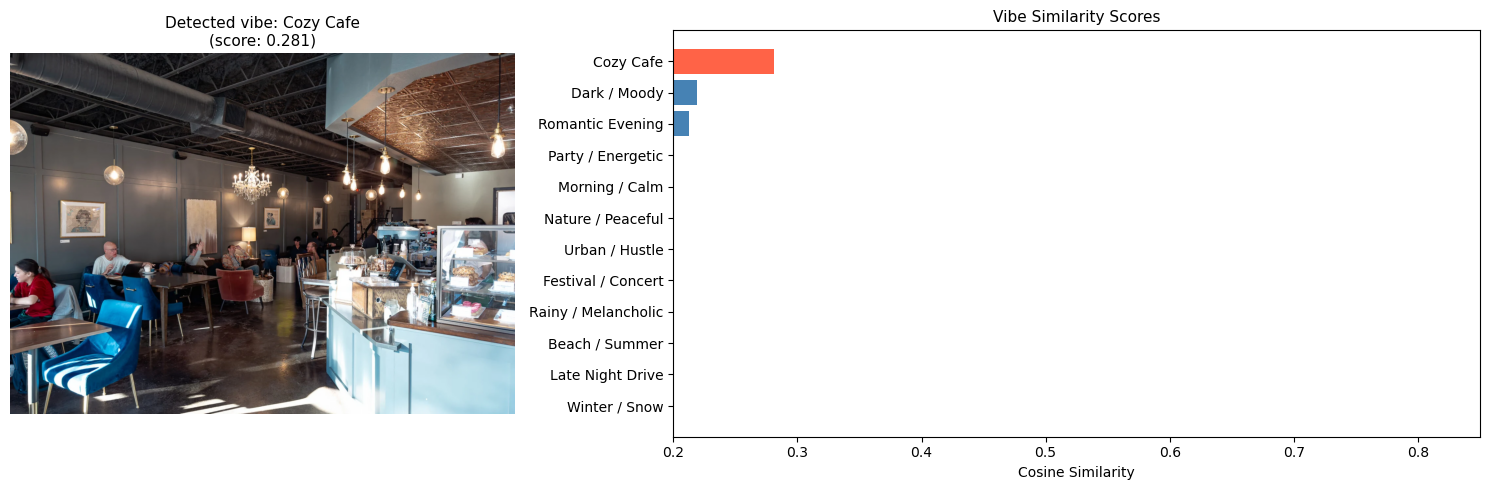


Top-10 Playlist — Cozy Cafe vibe

 rank  similarity               track_name                  artists      genres  popularity                                           spotify_url
    1      0.2501                Too Tired                Smartface       study          40 https://open.spotify.com/track/30ksReCEcSpnfAm8XCC4G7
    2      0.2482 be someone to never lose          Timmies;Mishaal  sad, chill          51 https://open.spotify.com/track/7pnU2BH8VbfPDNzqqCXjLh
    3      0.2455                  L-O-V-E            Nat King Cole        jazz          71 https://open.spotify.com/track/4QxDOjgpYtQDxxbWPuEJOy
    4      0.2418           Don't Know Why              Norah Jones jazz, j-pop          76 https://open.spotify.com/track/1zNXF2svmdlNxfS5XeNUgr
    5      0.2398                       OK              Canyon City    acoustic          55 https://open.spotify.com/track/2gBYjMXW65daBB1elr68JK
    6      0.2396                      Hoy           Los Solitarios rock-n-roll          

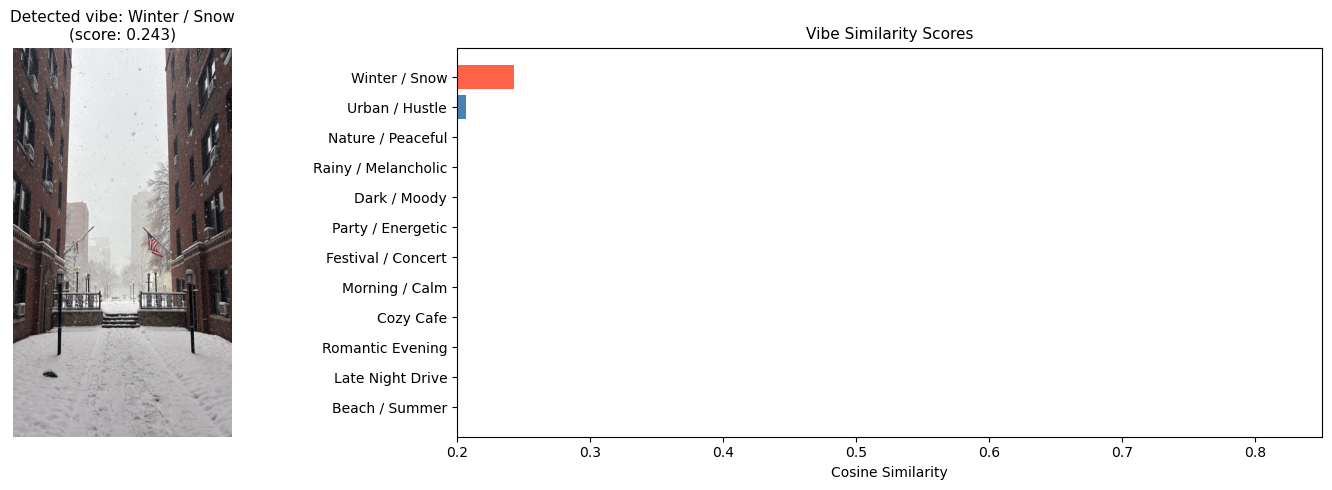


Top-10 Playlist — Winter / Snow vibe

 rank  similarity                                          track_name                         artists                 genres  popularity                                           spotify_url
    1      0.2449                                                Life                     Mark Farina          chicago-house          22 https://open.spotify.com/track/4A40YntAdkXYp9cQWyPdBi
    2      0.2438                         Dream Machine - Kaskade Mix             Mark Farina;Kaskade          chicago-house          44 https://open.spotify.com/track/7wlDCYTcXbNYF9RsKN5lpp
    3      0.2409                     Best of Wives and Best of Women Phillipa Soo;Lin-Manuel Miranda             show-tunes          58 https://open.spotify.com/track/1dZutYKh4BtPlxbC81wV34
    4      0.2393                                         Vårstämning                       Snowstorm                swedish          36 https://open.spotify.com/track/35k60P28fYCnT8TY1g3R0f
    5 

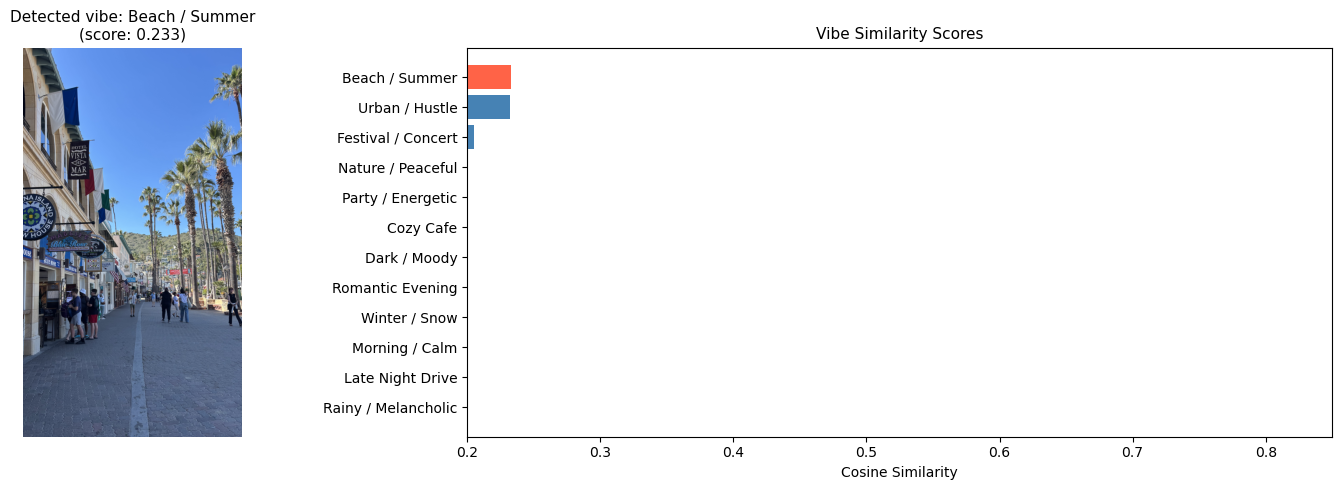


Top-10 Playlist — Beach / Summer vibe

 rank  similarity                                                             track_name                            artists            genres  popularity                                           spotify_url
    1      0.2697                                                         Hey DJ - Remix      CNCO;Meghan Trainor;Sean Paul reggaeton, reggae          60 https://open.spotify.com/track/3cR5ZtQ4JqGj4VHBb1gvFf
    2      0.2607 The Downeaster 'Alexa' - Live at Yankee Stadium, Bronx, NY - June 1990                         Billy Joel             piano          35 https://open.spotify.com/track/4d3OZBRQ5W7sOwLG8GyCGn
    3      0.2589               Pressure - Live at Yankee Stadium, Bronx, NY - June 1990                         Billy Joel             piano          35 https://open.spotify.com/track/5nJS0FYo9tPEo6drcq5kuf
    4      0.2588                      MIC Drop (Steve Aoki Remix) - Full Length Edition                     BTS;Steve Aoki     

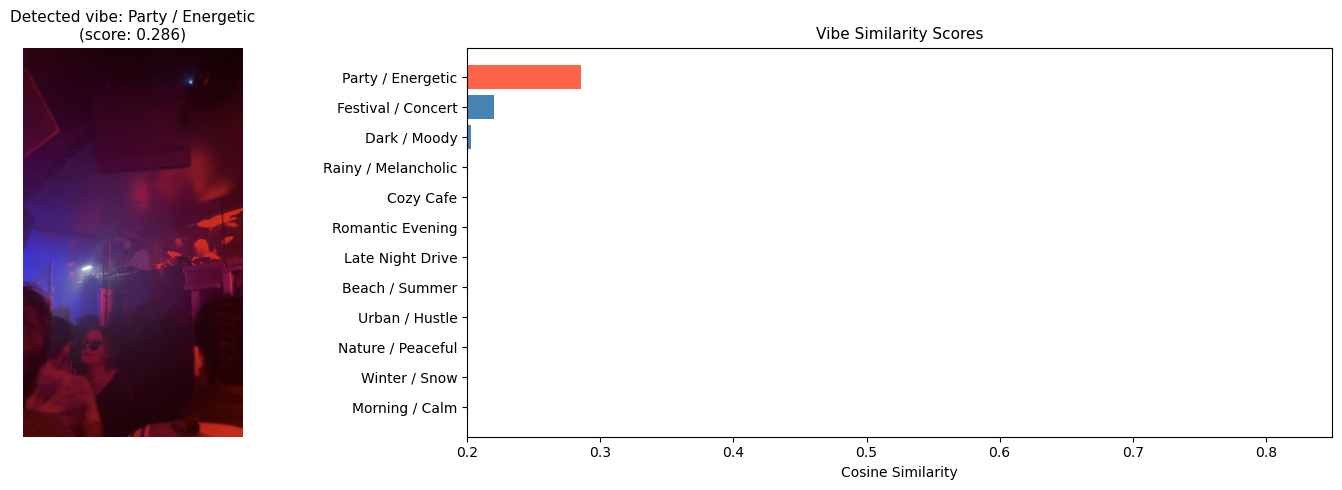


Top-10 Playlist — Party / Energetic vibe

 rank  similarity                           track_name                  artists             genres  popularity                                           spotify_url
    1      0.3015             ALL I NEED (feat. Drake)            Popcaan;Drake dancehall, j-dance          57 https://open.spotify.com/track/2VkusCBEW3EtnXdlZ3V3U5
    2      0.2867                         A Lo Natural           JuanchitoSaico          dancehall          31 https://open.spotify.com/track/1VAsseh5KzZ0Df9WqEmckq
    3      0.2864                              Shallow Lady Gaga;Bradley Cooper              dance          84 https://open.spotify.com/track/2VxeLyX666F8uXCJ0dZF8B
    4      0.2841                       Nada Nos Frena                El Shaaki          dancehall          28 https://open.spotify.com/track/7gKiBZpXR7bEVbSrknHdrh
    5      0.2829            Nyash (Current & Savings)                NSG;Giggs          dancehall          57 https://open.spotify.

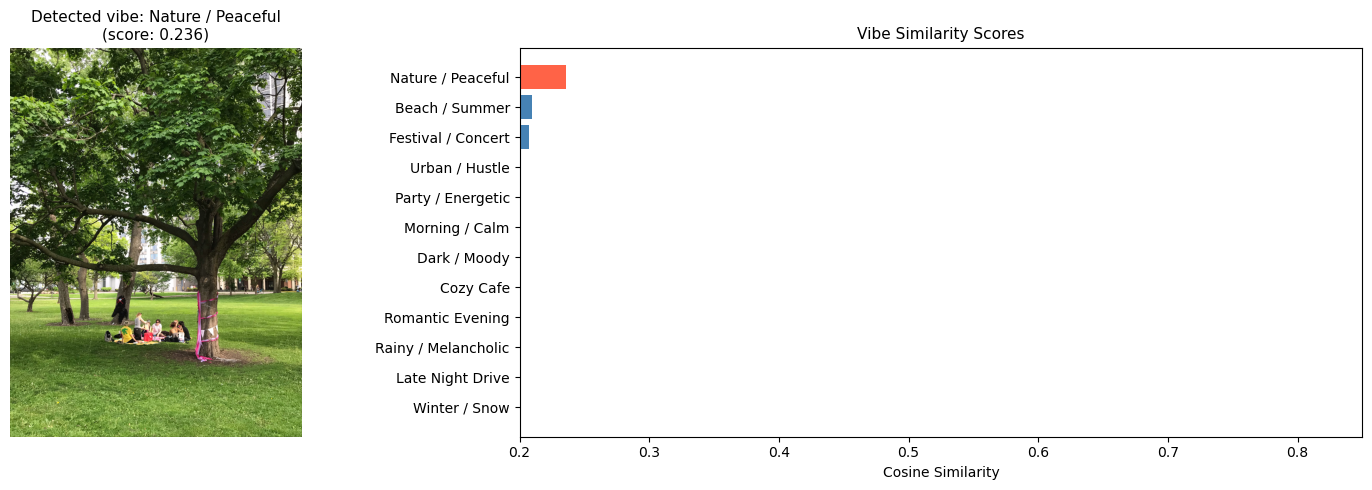


Top-10 Playlist — Nature / Peaceful vibe

 rank  similarity                    track_name                                                                                        artists                                         genres  popularity                                           spotify_url
    1      0.2532                         Again                                                                         Shiloh Dynasty;Timmies                                          chill          74 https://open.spotify.com/track/5e2l2ZAMwHmrkdM4Z6NhAR
    2      0.2527                    Hands Down                                                                                      2nd Grade                                      power-pop          21 https://open.spotify.com/track/1OJLDD8OIgOKFEhRiabD9N
    3      0.2514                    i like red                                                                                    Charlene Su                                          chill

In [8]:
os.makedirs("../data/sample_images", exist_ok=True)

TEST_IMAGES = {
    "Coffee shop" : "../data/sample_images/coffee_shop.jpg",
    "Snowy street": "../data/sample_images/snow_street.jpg",
    "Bright summer": "../data/sample_images/bright_summer.jpg",
    "Party"       : "../data/sample_images/party.jpg",
    "Nature"      : "../data/sample_images/nature.jpg",
}

# Run whichever images exist
for name, path in TEST_IMAGES.items():
    if os.path.exists(path):
        print(f"{'='*60}")
        print(f" Test: {name}")
        print(f"{'='*60}")
        show_result(path, top_k=10)
        print()
    else:
        print(f"[skipped] {name} — file not found at {path}")

---
### 5. Vibe detection: all scores

This cell shows the full vibe similarity breakdown for a single image.

In [9]:
IMAGE_PATH = "../data/sample_images/coffee_shop.jpg"

image = preprocess(Image.open(IMAGE_PATH).convert("RGB")).unsqueeze(0).to(device)
with torch.no_grad():
    img_emb = model.encode_image(image)
    img_emb = F.normalize(img_emb, dim=-1).cpu().numpy()

sims = (vibe_embeddings @ img_emb.T).squeeze()
vibe_score_df = pd.DataFrame({
    "vibe"      : vibe_labels,
    "similarity": sims.round(4),
}).sort_values("similarity", ascending=False).reset_index(drop=True)

print(f"Vibe scores for: {IMAGE_PATH}\n")
print(vibe_score_df.to_string(index=False))

Vibe scores for: ../data/sample_images/coffee_shop.jpg

               vibe  similarity
          Cozy Cafe      0.2812
       Dark / Moody      0.2189
   Romantic Evening      0.2125
  Party / Energetic      0.1946
     Morning / Calm      0.1932
  Nature / Peaceful      0.1784
     Urban / Hustle      0.1648
 Festival / Concert      0.1638
Rainy / Melancholic      0.1633
     Beach / Summer      0.1529
   Late Night Drive      0.1420
      Winter / Snow      0.1358


---
### 6. Baselines

To evaluate whether CLIP is doing anything useful, we compare against two baselines on the same test images:

| Baseline | Method | Expected behaviour |
|---|---|---|
| **Popularity** | Return the top-K tracks by Spotify popularity score | Strong baseline — popular songs are broadly liked, but genre-agnostic |
| **Random** | Sample K tracks uniformly at random | Weak baseline — establishes the floor |

A good CLIP recommendation should score **higher in user ratings** than both. If it doesn't beat popularity, the description quality or embedding alignment needs work.


In [10]:
def recommend_popularity(top_k: int = 10) -> pd.DataFrame:
    """
    Baseline 1 — Popularity.
    Returns the top_k tracks with the highest Spotify popularity score.
    No image, no CLIP — pure chart-topper selection.
    """
    top = index_df.nlargest(top_k, 'popularity')[[
        'track_name', 'artists', 'merged_genres', 'popularity'
    ]].reset_index(drop=True)
    top.insert(0, 'rank', top.index + 1)
    top.insert(1, 'method', 'popularity')
    return top


def recommend_random(top_k: int = 10, seed: int = None) -> pd.DataFrame:
    """
    Baseline 2 — Random.
    Samples top_k tracks uniformly at random from the song pool.
    Sets the floor for comparison — any method should beat this.
    """
    sample = index_df.sample(top_k, random_state=seed)[[
        'track_name', 'artists', 'merged_genres', 'popularity'
    ]].reset_index(drop=True)
    sample.insert(0, 'rank', sample.index + 1)
    sample.insert(1, 'method', 'random')
    return sample


# Quick demo
print('=== Popularity Baseline (top 10) ===')
print(recommend_popularity(10).to_string(index=False))
print()
print('=== Random Baseline (sample 10) ===')
print(recommend_random(10, seed=42).to_string(index=False))


=== Popularity Baseline (top 10) ===
 rank     method                            track_name                    artists                    merged_genres  popularity
    1 popularity             Unholy (feat. Kim Petras)       Sam Smith;Kim Petras                       dance, pop         100
    2 popularity Quevedo: Bzrp Music Sessions, Vol. 52           Bizarrap;Quevedo                          hip-hop          99
    3 popularity                            La Bachata              Manuel Turizo reggaeton, latino, reggae, latin          98
    4 popularity                       I'm Good (Blue)    David Guetta;Bebe Rexha                  pop, dance, edm          98
    5 popularity                      Tití Me Preguntó                  Bad Bunny latino, reggae, latin, reggaeton          97
    6 popularity                       Me Porto Bonito Bad Bunny;Chencho Corleone latino, latin, reggae, reggaeton          97
    7 popularity                                Efecto                  Ba

---
### 7. Labeled Test Set

To evaluate Phase 1 (vibe detection) we need a small set of images with ground-truth mood annotations.
The cell below defines the test set structure and saves it to `data/eval/test_set.csv`.

**Protocol:**
- Collect **at least 10 images** covering at least 6 distinct vibes (2 images per vibe minimum)
- Each image gets a `ground_truth_vibe` label chosen from the 12 keys in `VIBE_TAXONOMY`
- Vibe detection accuracy = fraction of images where the model's top vibe matches `ground_truth_vibe`
- Place test images in `data/eval/images/` before running


In [11]:
import os, csv

os.makedirs('../data/eval/images', exist_ok=True)

# ── Define labeled test images ───────────────────────────────────────────────
# 24 images: exactly 2 per vibe across all 12 vibe categories.
# ground_truth_vibe must be a key from VIBE_TAXONOMY.
TEST_SET = [
    # (filename,                      ground_truth_vibe,    notes)
    # cozy_cafe (2)
    ('coffee_shop_1.jpg',             'cozy_cafe',          'warm indoor lighting, people working quietly'),
    ('coffee_shop_2.jpg',             'cozy_cafe',          'coffee menu behind pastries and barista'),
    # winter_snow (2)
    ('snow_street_1.jpg',             'winter_snow',        'snow falling, snow-covered cars'),
    ('snow_street_2.jpg',             'winter_snow',        'quiet street, fresh snow'),
    # beach_summer (2)
    ('beach_day_1.jpg',               'beach_summer',       'bright sand, waves, woman reading'),
    ('beach_day_2.jpg',               'beach_summer',       'beach blanket with soft sand and water'),
    # rainy_melancholic (2)
    ('rainy_window_1.jpg',            'rainy_melancholic',  'grey sky, people with umbrellas'),
    ('rainy_window_2.jpg',            'rainy_melancholic',  'rainy park, gloomy and dark, wet park benches'),
    # party_energetic (2)
    ('party_1.jpg',                   'party_energetic',    'club, crowded dancefloor, coloured lights'),
    ('party_2.jpg',                   'party_energetic',    'crowded house party, dim lights'),
    # romantic_evening (2)
    ('romantic_dinner_1.jpg',         'romantic_evening',   'candlelit table for two'),
    ('romantic_dinner_2.jpg',         'romantic_evening',   'couple walking at night, park lights'),
    # nature_peaceful (2)
    ('nature_trail_1.jpg',            'nature_peaceful',    'forest with meadow and mountain'),
    ('nature_trail_2.jpg',            'nature_peaceful',    'forest with wooden bridge'),
    # urban_hustle (2)
    ('city_hustle_1.jpg',             'urban_hustle',       'busy intersection, midday'),
    ('city_hustle_2.jpg',             'urban_hustle',       'crowded subway platform'),
    # late_night_drive (2)
    ('late_night_drive_1.jpg',        'late_night_drive',   'highway at night, city glow'),
    ('late_night_drive_2.jpg',        'late_night_drive',   'empty road, headlights, dark sky'),
    # morning_calm (2)
    ('morning_window_1.jpg',          'morning_calm',       'sunlight through curtains'),
    ('morning_window_2.jpg',          'morning_calm',       'coffee mugs by a bright window at dawn'),
    # dark_moody (2)
    ('dark_moody_1.jpg',              'dark_moody',         'empty street in crowded trees, deep shadows'),
    ('dark_moody_2.jpg',              'dark_moody',         'dimly lit library, muted tones'),
    # festival_concert (2)
    ('concert_1.jpg',                 'festival_concert',   'outdoor festival'),
    ('concert_2.jpg',                 'festival_concert',   'crowd facing a lit stage'),
]

# Save test set manifest
EVAL_CSV = '../data/eval/test_set.csv'
with open(EVAL_CSV, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['filename', 'ground_truth_vibe', 'notes', 'image_path'])
    writer.writeheader()
    for filename, vibe, notes in TEST_SET:
        writer.writerow({
            'filename'         : filename,
            'ground_truth_vibe': vibe,
            'notes'            : notes,
            'image_path'       : f'../data/eval/images/{filename}',
        })

print(f'Test set manifest saved → {EVAL_CSV}')
print(f'{len(TEST_SET)} images defined across {len(set(v for _,v,_ in TEST_SET))} vibes (2 per vibe)')
print()
print('Next step: place your images in ../data/eval/images/ then run the evaluation cell below.')


Test set manifest saved → ../data/eval/test_set.csv
24 images defined across 12 vibes (2 per vibe)

Next step: place your images in ../data/eval/images/ then run the evaluation cell below.


---
### 8. Evaluation: CLIP vs Baselines

This section runs the full evaluation for demo day.

**What is measured:**
- **Vibe accuracy** — does the top detected vibe match the ground-truth label?
- **User rating (1–5)** — collected via the user study (see §8 below), averaged per method
- **Similarity score distribution** — sanity check that CLIP scores are meaningfully higher than random

**Success definition:** A recommendation is considered *good* when the average user rating
for the CLIP method exceeds both the popularity baseline and the random baseline by at
least 0.5 points on a 1–5 scale, across all raters and test images.


In [12]:
import os

eval_df = pd.read_csv('../data/eval/test_set.csv')

vibe_results = []

for _, row in eval_df.iterrows():
    path = row['image_path']
    if not os.path.exists(path):
        print(f'[skipped] {row["filename"]} — not found')
        continue

    vibe_key, vibe_lbl, vibe_score, all_sims, playlist = recommend_from_image(path, top_k=10)
    correct = (vibe_key == row['ground_truth_vibe'])

    vibe_results.append({
        'filename'          : row['filename'],
        'ground_truth'      : row['ground_truth_vibe'],
        'predicted_vibe'    : vibe_key,
        'correct'           : correct,
        'vibe_score'        : round(vibe_score, 4),
        'top_song'          : playlist.iloc[0]['track_name'] if len(playlist) else '',
        'mean_sim'          : round(float(playlist['similarity'].mean()), 4) if len(playlist) else 0,
    })

if vibe_results:
    results_df = pd.DataFrame(vibe_results)
    accuracy   = results_df['correct'].mean()
    print(f'Vibe detection accuracy: {accuracy:.1%} ({results_df["correct"].sum()}/{len(results_df)} correct)')
    print()
    print(results_df[['filename', 'ground_truth', 'predicted_vibe', 'correct', 'vibe_score']].to_string(index=False))
    results_df.to_csv('../data/eval/vibe_accuracy_results.csv', index=False)
    print('\nResults saved → ../data/eval/vibe_accuracy_results.csv')
else:
    print('No test images found. Add images to ../data/eval/images/ first.')


Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Looking up tracks on Spotify...
Vibe detection accuracy: 83.3% (20/24 correct)

              filename      ground_truth    predicted_vibe  correct  vibe_score
     coffee_shop_1.jpg         cozy_cafe         cozy_cafe     True      0.2714
     coffee_shop_2.jpg  

---
### 9. User Study Protocol

**Purpose:** Collect subjective ratings to compare CLIP recommendations against the two baselines.

**Participants:** 5 raters (group members + 2 external classmates is sufficient for a class project).

**Stimuli:** 10 test images (1 per vibe category, chosen from `test_set.csv`).

**Procedure per image (per rater):**
1. Show the image for 5 seconds.
2. Show three playlists (10 songs each) in random order, labeled only as A / B / C — raters are blind to which method produced which.
3. Rater assigns a rating 1–5 to each playlist:
   - **5** — Every song fits the image's mood perfectly
   - **4** — Most songs fit well
   - **3** — About half fit, half don't
   - **2** — Only a few songs fit
   - **1** — No songs match the mood at all

**Aggregation:**
- Mean rating per method across all images and raters
- Inter-rater agreement: Krippendorff's alpha (acceptable ≥ 0.6)
- Report: mean ± std per method; paired t-test CLIP vs popularity, CLIP vs random

**Success criterion:** CLIP mean rating ≥ popularity mean + 0.5 AND ≥ random mean + 1.0

Run the rating collector below to gather and save scores.


In [13]:
# ── User study rating collector ──────────────────────────────────────────────
# Fill in ratings after running the study. Each entry is one rater × one image.
# method: 'clip' | 'popularity' | 'random'
# rating: integer 1–5

RATINGS = [
    # {'rater': 'R1', 'image': 'coffee_shop_1.jpg', 'method': 'clip',       'rating': 4},
    # {'rater': 'R1', 'image': 'coffee_shop_1.jpg', 'method': 'popularity', 'rating': 3},
    # {'rater': 'R1', 'image': 'coffee_shop_1.jpg', 'method': 'random',     'rating': 1},
    # ... add all rater × image × method combinations here
]

if RATINGS:
    ratings_df = pd.DataFrame(RATINGS)
    ratings_df.to_csv('../data/eval/user_ratings.csv', index=False)

    summary = (
        ratings_df.groupby('method')['rating']
        .agg(mean='mean', std='std', n='count')
        .round(3)
        .sort_values('mean', ascending=False)
    )
    print('=== User Study Results ===')
    print(summary.to_string())

    # Plot
    import matplotlib.pyplot as plt
    methods = summary.index.tolist()
    means   = summary['mean'].tolist()
    stds    = summary['std'].tolist()
    colors  = ['tomato' if m == 'clip' else 'steelblue' for m in methods]

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(methods, means, yerr=stds, capsize=5, color=colors)
    ax.set_ylim(0, 5.5)
    ax.axhline(y=summary.loc['clip', 'mean'] - 0.5, color='grey',
               linestyle='--', linewidth=0.8, label='CLIP - 0.5 threshold')
    ax.set_ylabel('Mean rating (1–5)')
    ax.set_title('User Study: Mean Playlist Rating by Method')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('No ratings entered yet. Fill in the RATINGS list after conducting the user study.')


No ratings entered yet. Fill in the RATINGS list after conducting the user study.


---
### Summary

**Representation:** Each song is a natural-language description (not raw audio features),
enabling direct cosine comparison with CLIP image embeddings in the shared 512-d space.

**Pipeline:**
```
Image
  │
  ▼
CLIP image encoder → 512-d image embedding
  │
  ├──► vs. 12 vibe probe embeddings  →  top vibe label  (display only)
  │
  └──► vs. 61,670 song embeddings    →  cosine similarity per song  →  diverse top-K playlist
```

**Baselines for comparison:**
- `recommend_popularity()` — top-K by Spotify popularity (strong baseline)
- `recommend_random()` — uniform random sample (floor baseline)

**Evaluation:**
- Vibe accuracy on labeled test set (`data/eval/test_set.csv`)
- User ratings 1–5, 5 raters × 10 images × 3 methods, averaged and compared
- Success: CLIP mean rating ≥ popularity + 0.5 and ≥ random + 1.0
